Author: Catherine Gatt

Date: 24/02/2026

Content: 
UMAP embedding and fly marker genes visualisation Figure 1C, 1D, 1E

In [1]:

print('hello')
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import rc_context

h5ad_file = "/home/catherine/phd/projects/termites/data/znev/combined_no_norm_clustered.h5ad"
adata = sc.read_h5ad(h5ad_file)



hello


In [2]:
## cell type numbers AFTER annotation 

col = "paper_cell_type_annotation"

# Ensure string
labels = adata.obs[col].astype(str)

# Identify T-number types (e.g. T1, T23)
is_T_number = labels.str.match(r"^T\d+$")

# Unique counts
unique_T_types = labels[is_T_number].nunique()
unique_named_types = labels[~is_T_number].nunique()

print(f"Unique T-number types: {unique_T_types}")
print(f"Unique named cell types: {unique_named_types}")

print("T-number types:")
print(sorted(labels[is_T_number].unique()))

print("\nNamed types:")
print(sorted(labels[~is_T_number].unique()))


Unique T-number types: 6
Unique named cell types: 18
T-number types:
['T1', 'T2', 'T3', 'T4', 'T5', 'T6']

Named types:
['CNS neuron', 'Malpighian tubule stellate', 'antimicrobial', 'cardiac cell', 'crystal cell', 'epithelial', 'excretory', 'fat cell', 'female reproductive system', 'glial cell', 'gustatory neuron', 'hemocyte', 'intestinal progenitor like', 'muscle cell', 'neuron', 'oenocyte', 'sensory neuron', 'stem cell']


In [3]:
col = "leiden"

# Ensure string (optional but safe)
leiden_labels = adata.obs[col].astype(str)

# Number of unique clusters
n_unique = leiden_labels.nunique()

print(f"Number of unique Leiden clusters: {n_unique}")

print("\nUnique Leiden cluster IDs:")
print(sorted(leiden_labels.unique()))


Number of unique Leiden clusters: 33

Unique Leiden cluster IDs:
['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '4', '5', '6', '7', '8', '9']


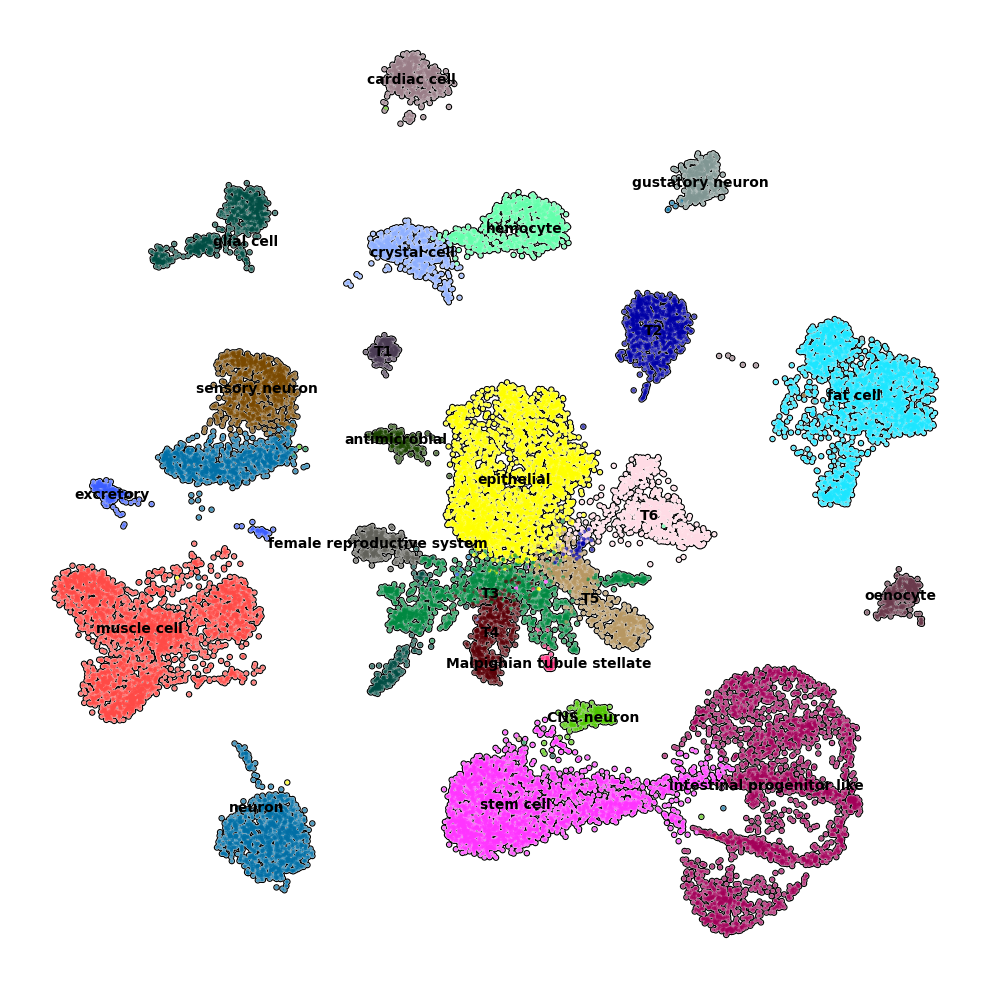

In [4]:
# Figure 1C UMAP

fig, axs = plt.subplots(1, 1, figsize=(10, 10))
axs.set_axis_off()
sc.pl.umap(
    adata,
    color='paper_cell_type_annotation',
    ax=axs,
    add_outline=True,
    s=30,
    show=False,  
    title="",
    legend_loc='on data'
)

handles, labels = axs.get_legend_handles_labels()

'''if handles:
    axs.legend(
        handles, labels, 
        loc='center left',  
        bbox_to_anchor=(1.05, 0.5),  
        ncol=1,  
        fontsize=10, 
        frameon=False 
    )
'''
fig.tight_layout()
plt.savefig("umap.png", dpi=600)

plt.show()



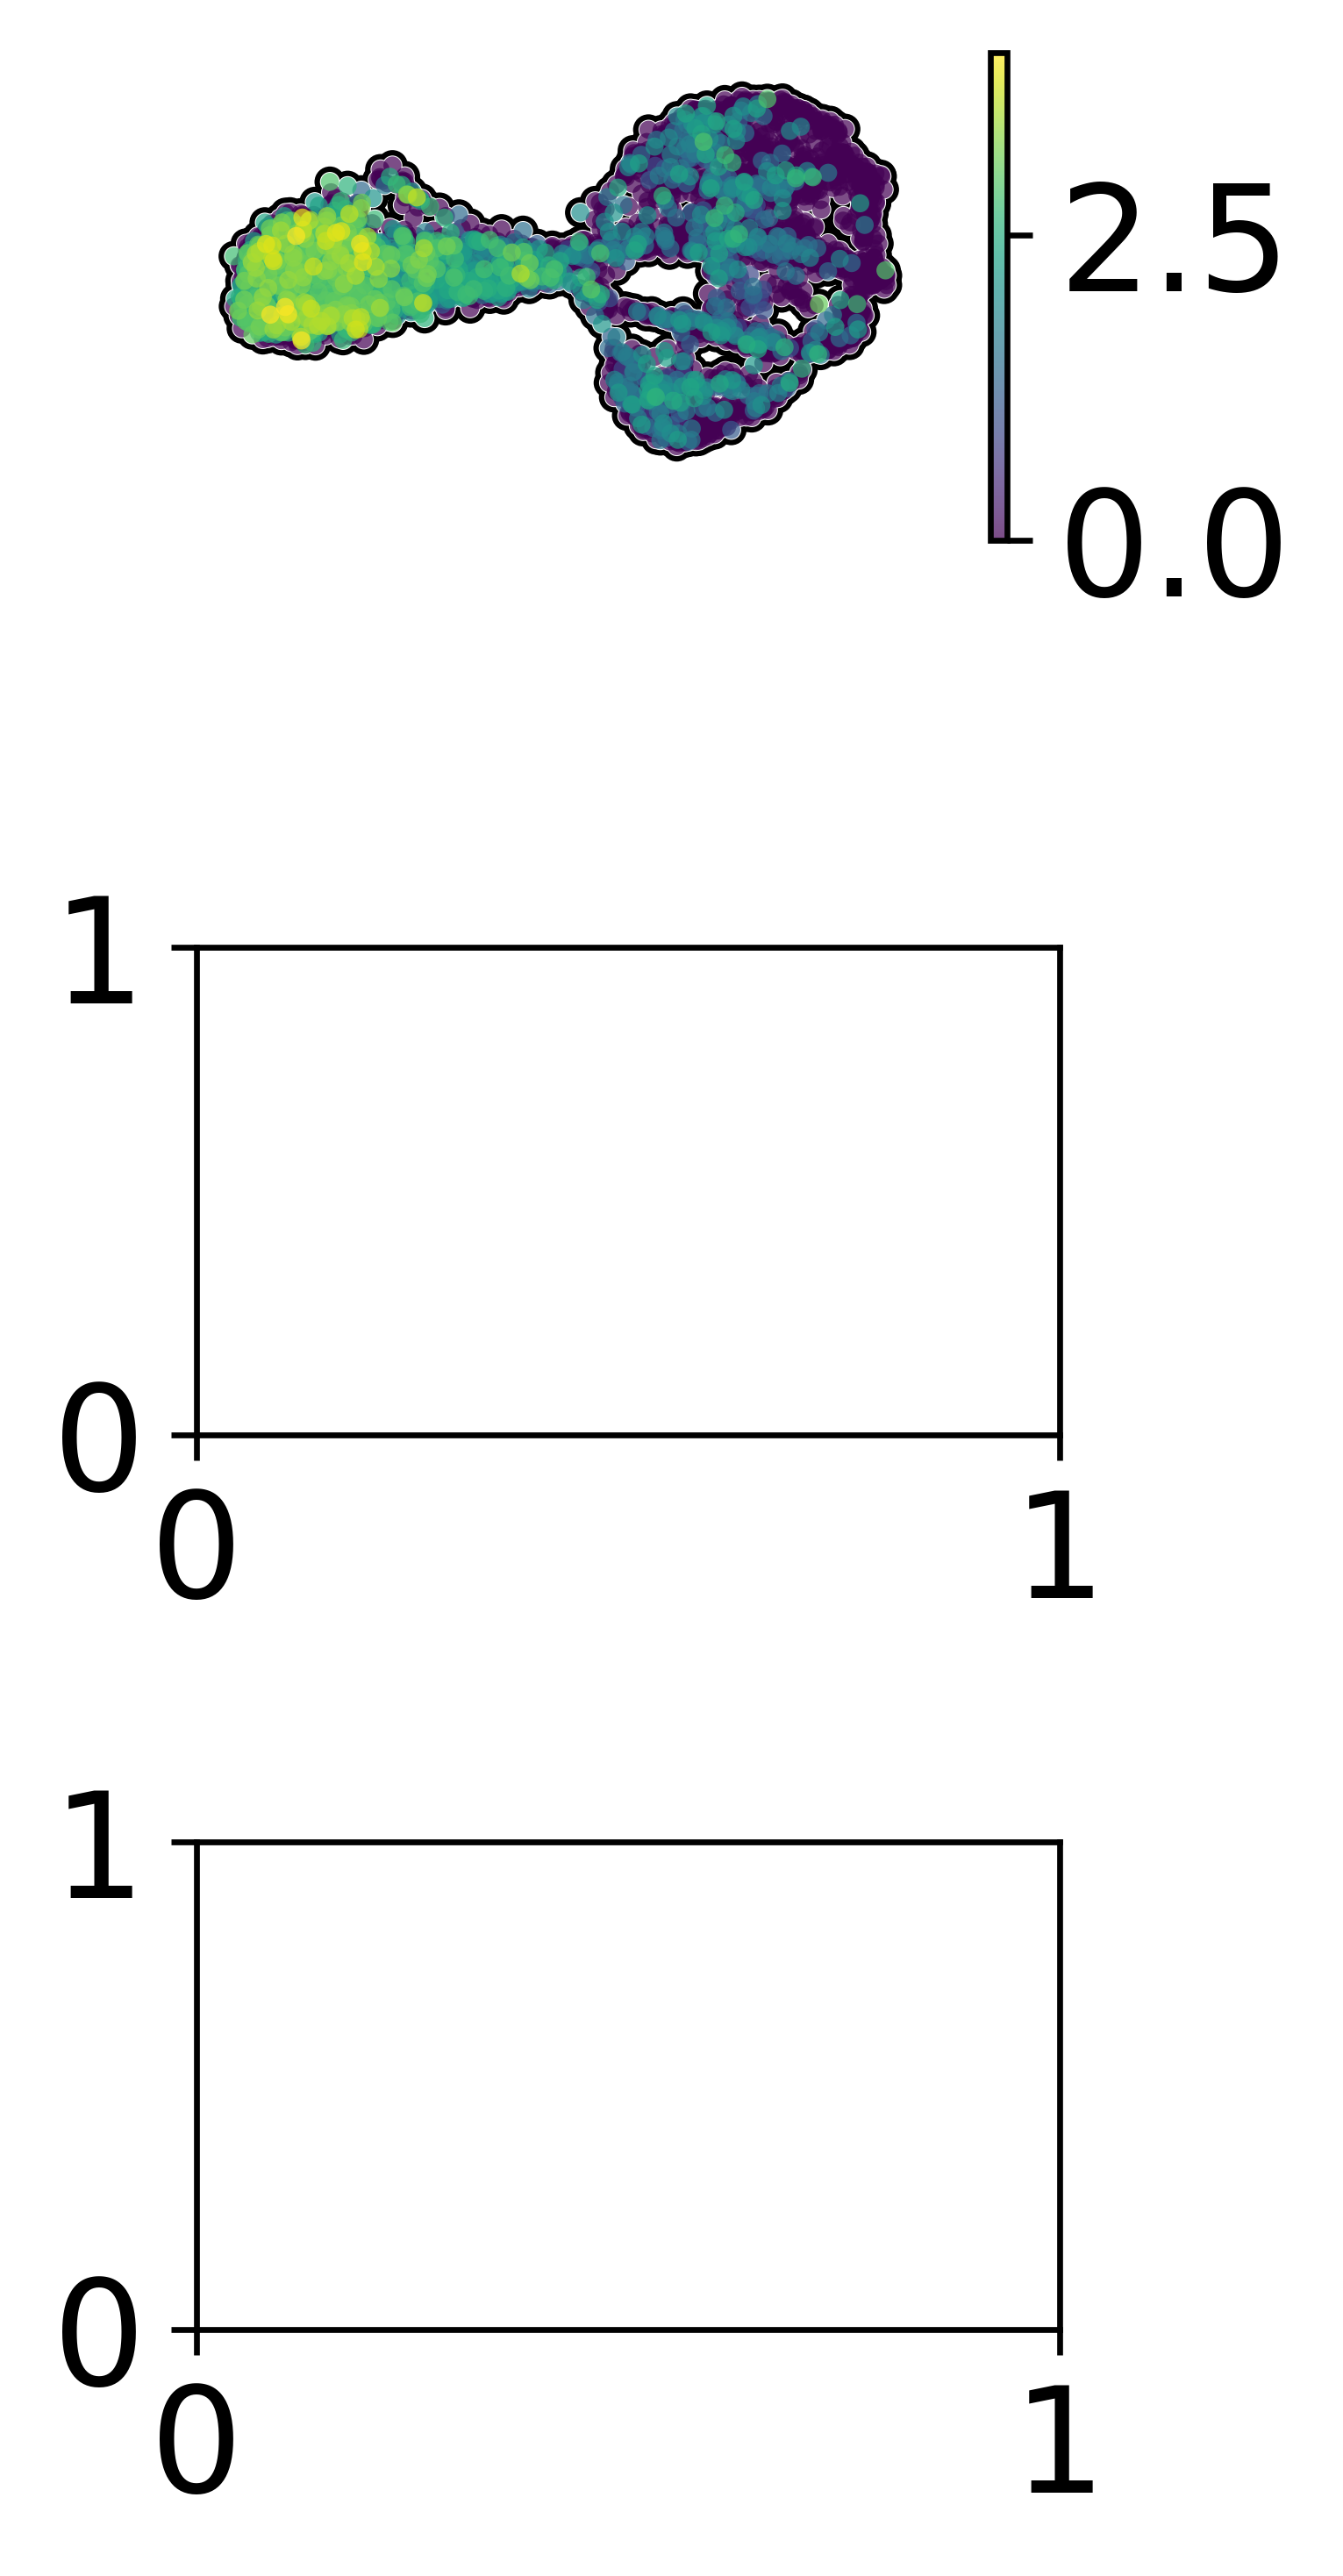

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

# -----------------------------
# Subset to only the two cell types
# -----------------------------
cell_types_to_keep = ["stem cell", "intestinal progenitor like"]
celltype_col = "paper_cell_type_annotation"   # change if different

adata_sub = adata[adata.obs[celltype_col].isin(cell_types_to_keep)].copy()

# -----------------------------
# Genes
# -----------------------------
# sox 100B
#genes = ['Znev00000082']

# klu
genes = ['Znev00010248']



# Smaller font
sc.set_figure_params(fontsize=20)

# Create figure
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(3.0, 5.4), dpi=300)

# -----------------------------
# UMAP plots (subset only)
# -----------------------------
for gene, ax in zip(genes, axes):
    sc.pl.umap(
        adata_sub,
        color=gene,
        ax=ax,
        show=False,
        title=None,
        frameon=False,
        color_map='viridis',
        vmax=4,
        add_outline=True
    )

    ax.set_title("")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(2.5, 17)
    ax.set_ylim(-10, 2)   

plt.tight_layout()
plt.savefig("stem_umap.png", dpi=600)
plt.show()


In [6]:
print(sorted(adata.obs['paper_cell_type_annotation'].unique().tolist()))

['CNS neuron', 'Malpighian tubule stellate', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'antimicrobial', 'cardiac cell', 'crystal cell', 'epithelial', 'excretory', 'fat cell', 'female reproductive system', 'glial cell', 'gustatory neuron', 'hemocyte', 'intestinal progenitor like', 'muscle cell', 'neuron', 'oenocyte', 'sensory neuron', 'stem cell']


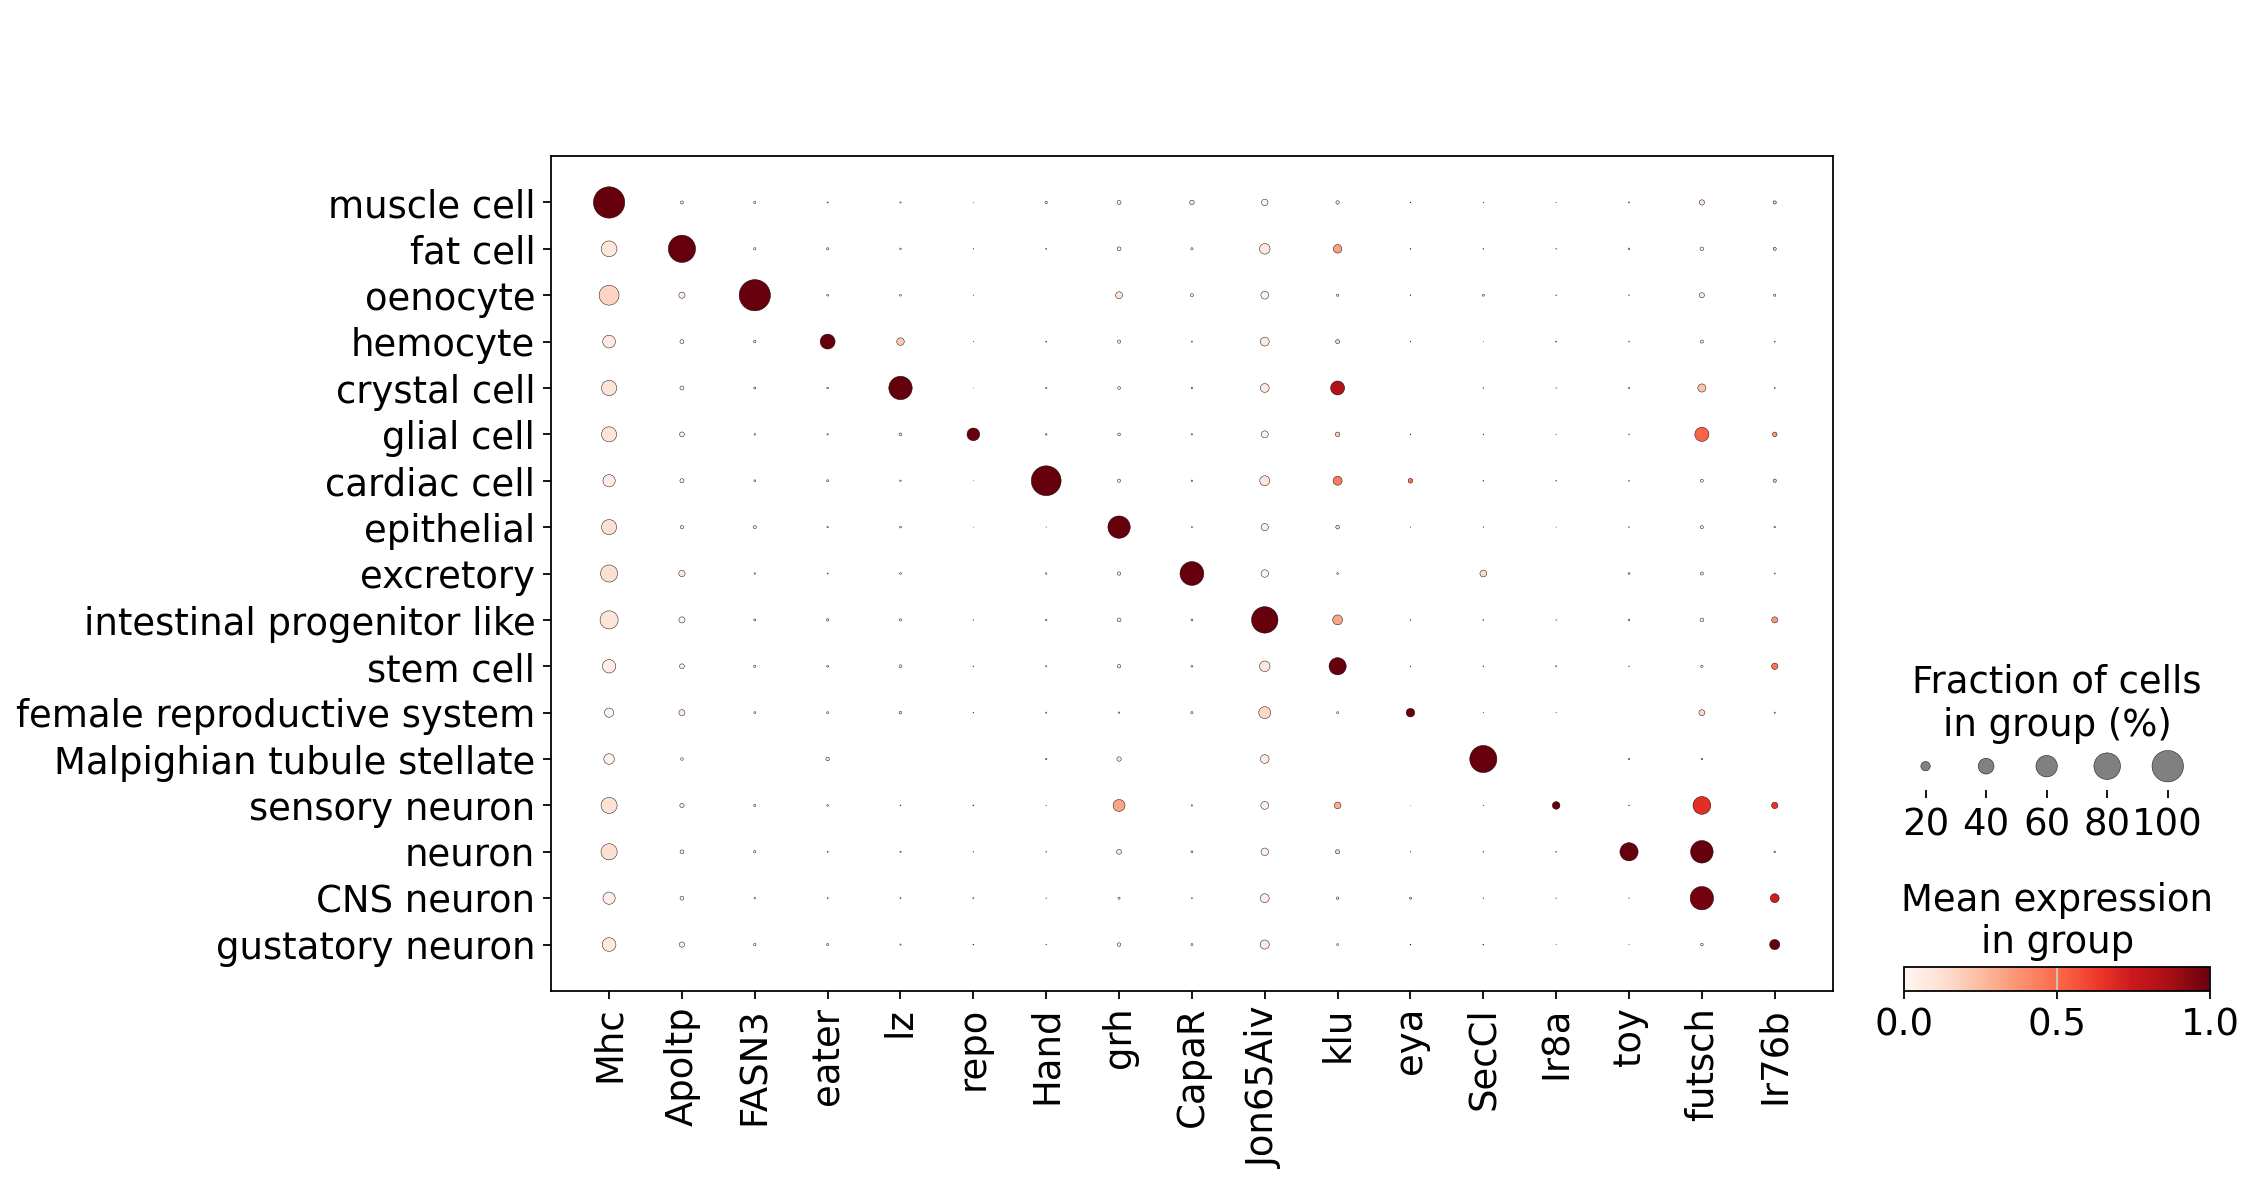

In [21]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

# -------------------- CONFIG --------------------
custom_gene_dict = {
    'muscle cell': ['Znev00001420'],
    'fat cell': ['Znev00012632'],
    'oenocyte': ['Znev00011328'],
    'hemocyte': ['Znev00008859'],
    'crystal cell': ['Znev00006915'],
    'glial cell': ['Znev00010154'],
    'cardiac cell': ["Znev00003479"],
    'epithelial': ["Znev00012349"],
    'excretory': ["Znev00007841"],
    'intestinal progenitor like': ['Znev00007834'],
    'stem cell': ['Znev00010248'],
    'female reproductive system': ['Znev00000977'],
    'Malpighian tubule stellate': ['Znev00002897'],
    'sensory neuron': ['Znev00003589'],
    'neuron': ['Znev00007487'],
    'CNS neuron': ['Znev00011721'],
    'gustatory neuron': ['Znev00012231'],
    
}

FIGSIZE = (14.5, 7.8)


# ----------------- PREP DATA --------------------
cell_types_to_include = list(custom_gene_dict.keys())
adata_subset = adata[adata.obs['paper_cell_type_annotation'].isin(cell_types_to_include)].copy()
adata_subset.obs['paper_cell_type_annotation'] = pd.Categorical(
    adata_subset.obs['paper_cell_type_annotation'],
    categories=cell_types_to_include,
    ordered=True
)

flattened_genes = [g for genes in custom_gene_dict.values() for g in genes]

# Ortholog labels for x-axis genes
display_labels = []
for gene in flattened_genes:
    sym = None
    if gene in adata.var.index and 'dmel_gene_symbol' in adata.var.columns:
        sym = adata.var.loc[gene, 'dmel_gene_symbol']
    display_labels.append(sym if (pd.notna(sym) and sym) else gene)

# Group positions
group_positions = []
start = 0
for ct in custom_gene_dict:
    n = len(custom_gene_dict[ct])
    if n > 0:
        group_positions.append((start, start + n - 1))
        start += n

# Multiline helper: only split if exactly three words
def multiline(name: str) -> str:
    parts = str(name).split()
    if len(parts) == 4:
        return " ".join(parts[:2]) + "\n" + parts[2]
    else:
        return name

# >>> Do NOT wrap cell-type names on the side (y-axis):
pretty_cell_types = cell_types_to_include  # no newlines

# You can still wrap the top gene-group labels if you want:
pretty_group_labels = [multiline(ct) for ct in custom_gene_dict.keys()]

# ------------------- PLOT -----------------------
fig, ax = plt.subplots(figsize=FIGSIZE)

axes_dict = sc.pl.dotplot(
    adata_subset,
    var_names=flattened_genes,
    groupby='paper_cell_type_annotation',
    #var_group_positions=group_positions,
    #var_group_labels=pretty_group_labels,
    #vmax=1,
    #dot_max=0.3,
    standard_scale='var',
    show=False,
    ax=ax
)

# --- Adjust fonts on all parts ---
main_ax = axes_dict.get("mainplot_ax", None)
if main_ax is not None:
    main_ax.set_xticklabels(display_labels, rotation=90, ha='center')
    # Use unwrapped cell-type names on the side
    main_ax.set_yticklabels(pretty_cell_types)



plt.tight_layout()
plt.savefig("marker_dot_plot.png", dpi=600)

plt.show()


In [8]:
display_labels

['Mhc',
 'Apoltp',
 'FASN3',
 'eater',
 'lz',
 'repo',
 'Hand',
 'grh',
 'CapaR',
 'Jon65Aiv',
 'Sox100B',
 'eya',
 'SecCl',
 'Ir8a',
 'toy',
 'futsch',
 'Ir76b']

In [9]:
custom_gene_dict = {
    'muscle cell': ['Znev00001420', 'Znev00007256'],
    'fat cell': ['Znev00012632', 'Znev00000840'],
    'oenocyte': ['Znev00011328', 'Znev00011277'],
    'hemocyte': ['Znev00008934', 'Znev00008859'],
    'crystal cell': ['Znev00006915', 'Znev00004272'],
    'sensory neuron': ['Znev00003589', 'Znev00012924'],
    'neuron': ['Znev00007487', 'Znev00001860'],
    'CNS neuron': ['Znev00011721'],
    'gustatory neuron': ['Znev00012231'],
    'glial cell': ['Znev00010154', 'Znev00013186'],
    'cardial cell': ["Znev00003479"],
    'epithelial': ["Znev00012349", "Znev00002529"],
    'excretory': ["Znev00007841",  "Znev00011165"],
    'intestinal progenitor like': ['Znev00007834','Znev00007245'],
    'female reproductive system': ['Znev00000977', 'Znev00012820'],
    
    'Malpighian tubule stellate': ['Znev00002897'],
    
}
